In [26]:
import pandas as pd

# load the test data
df_test = pd.read_csv("feature_store/v1/test_data.csv")
df_test.head(3)

,Blue_max,Blue_mean,Blue_min,Blue_quadrant_0_max,Blue_quadrant_0_mean,Blue_quadrant_0_min,Blue_quadrant_0_std,Blue_quadrant_1_max,Blue_quadrant_1_mean,Blue_quadrant_1_min,...,Red_quadrant_2_max,Red_quadrant_2_mean,Red_quadrant_2_min,Red_quadrant_2_std,Red_quadrant_3_max,Red_quadrant_3_mean,Red_quadrant_3_min,Red_quadrant_3_std,Red_std,label_idx
0,170.0,116.350830,84.0,159.0,117.323242,91.0,19.236755,165.0,118.451172,88.0,...,186.0,99.802734,53.0,34.455164,181.0,97.981445,48.0,37.060242,36.004263,0
1,255.0,141.962158,109.0,202.0,127.222656,109.0,12.502782,255.0,134.246094,111.0,...,255.0,100.809570,51.0,42.346343,253.0,111.212891,51.0,55.470164,43.616855,4
2,197.0,113.969238,80.0,197.0,93.231445,86.0,11.664840,191.0,116.820312,86.0,...,216.0,94.850586,53.0,54.620710,219.0,183.094727,58.0,35.169759,62.697709,0


In [27]:
import json

# load map_idx2labels
with open("feature_store/v1/map_idx2labels.json", "r") as f:
    map_idx2labels = json.load(f)

map_idx2labels

{'0': 'AnnualCrop',
 '1': 'Forest',
 '2': 'HerbaceousVegetation',
 '3': 'Highway',
 '4': 'Industrial',
 '5': 'Pasture',
 '6': 'PermanentCrop',
 '7': 'Residential',
 '8': 'River',
 '9': 'SeaLake'}

In [28]:
import os

# get the label names from the data directory
data_dir = 'datasets/EuroSAT_RGB/'
label_names = sorted(os.listdir(data_dir))
label_names.remove('.DS_Store')
label_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [29]:
import joblib

# load best model from model-registry
model = joblib.load("model_registry/v1/best_model.pkl")
model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [30]:
# make predictions on the test set
y_pred = model.predict(df_test.drop(columns=["label_idx"]).values)

assert len(y_pred) == len(df_test), "Number of predictions does not match number of test samples"

In [34]:
# add predictions to the test dataframe
df_test["pred_idx"] = y_pred
# cast as string for mapping
df_test['label_idx'] = df_test['label_idx'].astype(str)
df_test['pred_idx'] = df_test['pred_idx'].astype(str)
df_test['true_label'] = df_test['label_idx'].map(map_idx2labels)
df_test['pred_label'] = df_test['pred_idx'].map(map_idx2labels)
df_test.head(3)

,Blue_max,Blue_mean,Blue_min,Blue_quadrant_0_max,Blue_quadrant_0_mean,Blue_quadrant_0_min,Blue_quadrant_0_std,Blue_quadrant_1_max,Blue_quadrant_1_mean,Blue_quadrant_1_min,...,Red_quadrant_2_std,Red_quadrant_3_max,Red_quadrant_3_mean,Red_quadrant_3_min,Red_quadrant_3_std,Red_std,label_idx,pred_idx,true_label,pred_label
0,170.0,116.350830,84.0,159.0,117.323242,91.0,19.236755,165.0,118.451172,88.0,...,34.455164,181.0,97.981445,48.0,37.060242,36.004263,0,3,AnnualCrop,Highway
1,255.0,141.962158,109.0,202.0,127.222656,109.0,12.502782,255.0,134.246094,111.0,...,42.346343,253.0,111.212891,51.0,55.470164,43.616855,4,4,Industrial,Industrial
2,197.0,113.969238,80.0,197.0,93.231445,86.0,11.664840,191.0,116.820312,86.0,...,54.620710,219.0,183.094727,58.0,35.169759,62.697709,0,0,AnnualCrop,AnnualCrop


## debug testing
* ### check misclassified instances
* ### check interpretability per instance

In [35]:
test_df_misclassified = df_test[df_test['label_idx'] != df_test['pred_idx']]
test_df_misclassified.head(3)

,Blue_max,Blue_mean,Blue_min,Blue_quadrant_0_max,Blue_quadrant_0_mean,Blue_quadrant_0_min,Blue_quadrant_0_std,Blue_quadrant_1_max,Blue_quadrant_1_mean,Blue_quadrant_1_min,...,Red_quadrant_2_std,Red_quadrant_3_max,Red_quadrant_3_mean,Red_quadrant_3_min,Red_quadrant_3_std,Red_std,label_idx,pred_idx,true_label,pred_label
0,170.0,116.350830,84.0,159.0,117.323242,91.0,19.236755,165.0,118.451172,88.0,...,34.455164,181.0,97.981445,48.0,37.060242,36.004263,0,3,AnnualCrop,Highway
10,255.0,138.882324,87.0,255.0,149.958008,87.0,40.475026,245.0,157.128906,92.0,...,40.125100,255.0,138.284180,80.0,43.038889,49.859839,2,4,HerbaceousVegetation,Industrial
12,255.0,113.484863,89.0,125.0,108.060547,97.0,3.337793,160.0,111.207031,95.0,...,15.546557,255.0,95.835938,47.0,24.329132,15.925251,3,7,Highway,Residential


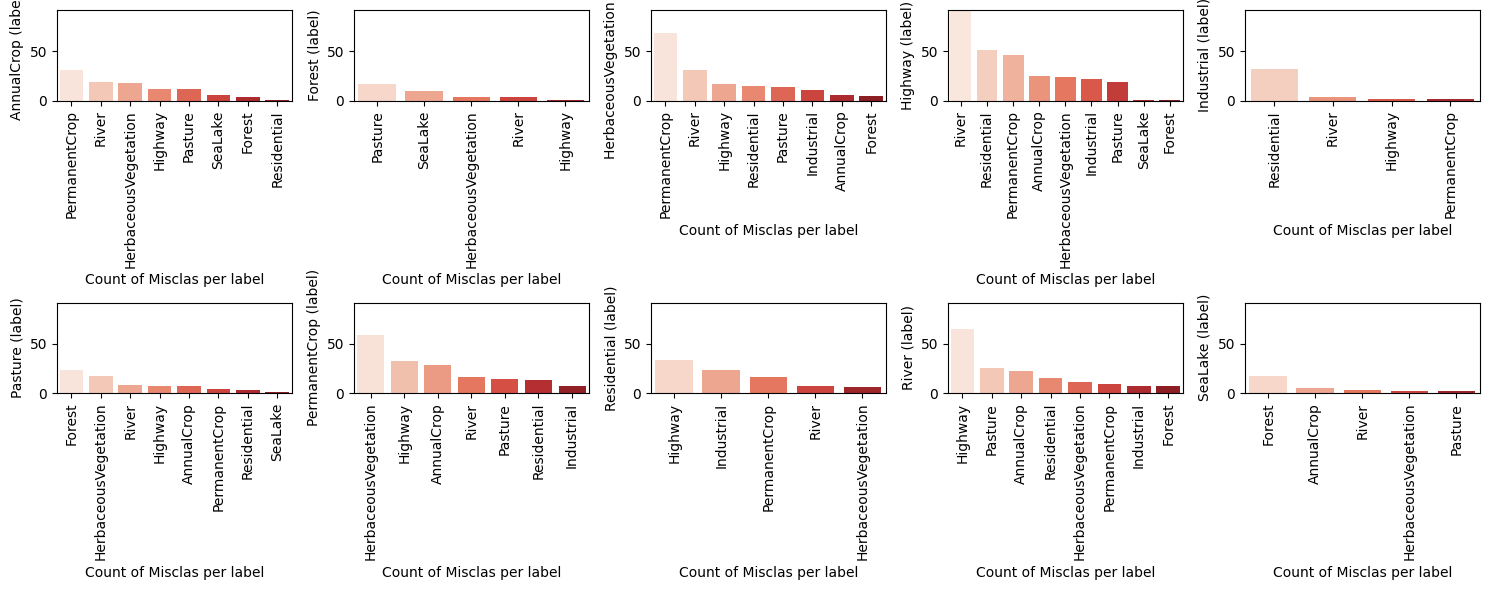

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

## create list of dict where each dict has keys: true label, other labels count
misclassified_summary = []
for true_label in label_names:
    subset = test_df_misclassified[test_df_misclassified['true_label'] == true_label]
    other_labels_count = subset['pred_label'].value_counts().to_dict()
    misclassified_summary.append({
        'true_label': true_label,
        'other_labels_count': other_labels_count
    })

max_value = 0
for summary in misclassified_summary:
    max_value = max(max_value, max(summary['other_labels_count'].values()))

# plot misclassification patterns
plt.figure(figsize=(15, 6))
for i, summary in enumerate(misclassified_summary):
    true_label = summary['true_label']
    other_labels_count = summary['other_labels_count']
    plt.subplot(2, 5, i + 1)
    sns.barplot(x=list(other_labels_count.keys()), 
                y=list(other_labels_count.values()), 
                palette='Reds', 
                hue=list(other_labels_count.keys())
        )
    plt.xticks(rotation=90)
    plt.ylabel(f"{true_label} (label)")
    plt.xlabel('Count of Misclas per label')
    plt.ylim(0, max_value + 1)
plt.tight_layout()
plt.show()

## Debug model in training

* ### check feature importance scores per class
* ### check feature importance scores all trees
* ### check single tree
* ### check similarity in feature importance scores between classes 

In [ ]:
import joblib

with open("model_registry/v1/best_model.pkl", "rb") as f:
    best_model = joblib.load(f)

dict_tree_importances_per_class = {}
for s, stage in enumerate(best_model.estimators_):
    for c, tree in enumerate(stage):
        if c not in dict_tree_importances_per_class:
            dict_tree_importances_per_class[c] = {}
        dict_tree_importances_per_class[c][s] = tree.feature_importances_

feature_names = df_test.drop(columns=["label_idx", "pred_idx", "true_label", "pred_label"]).columns.tolist()

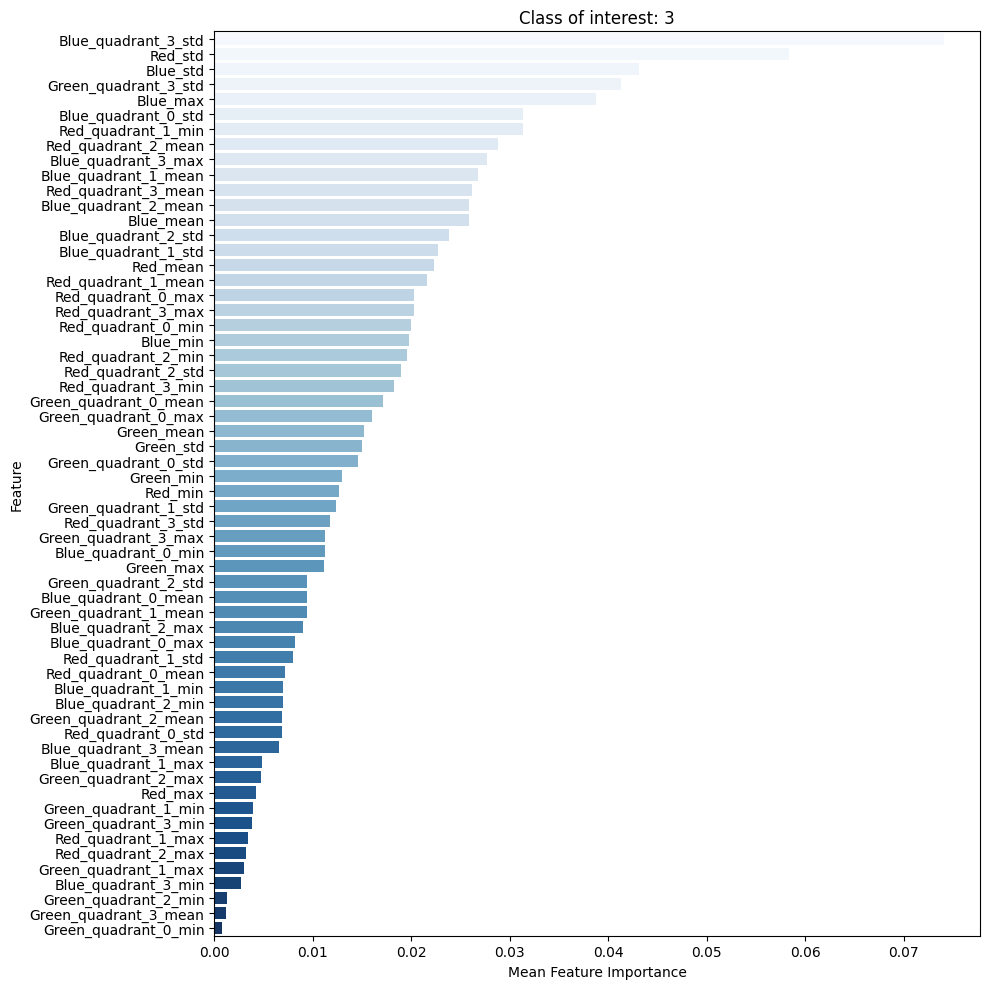

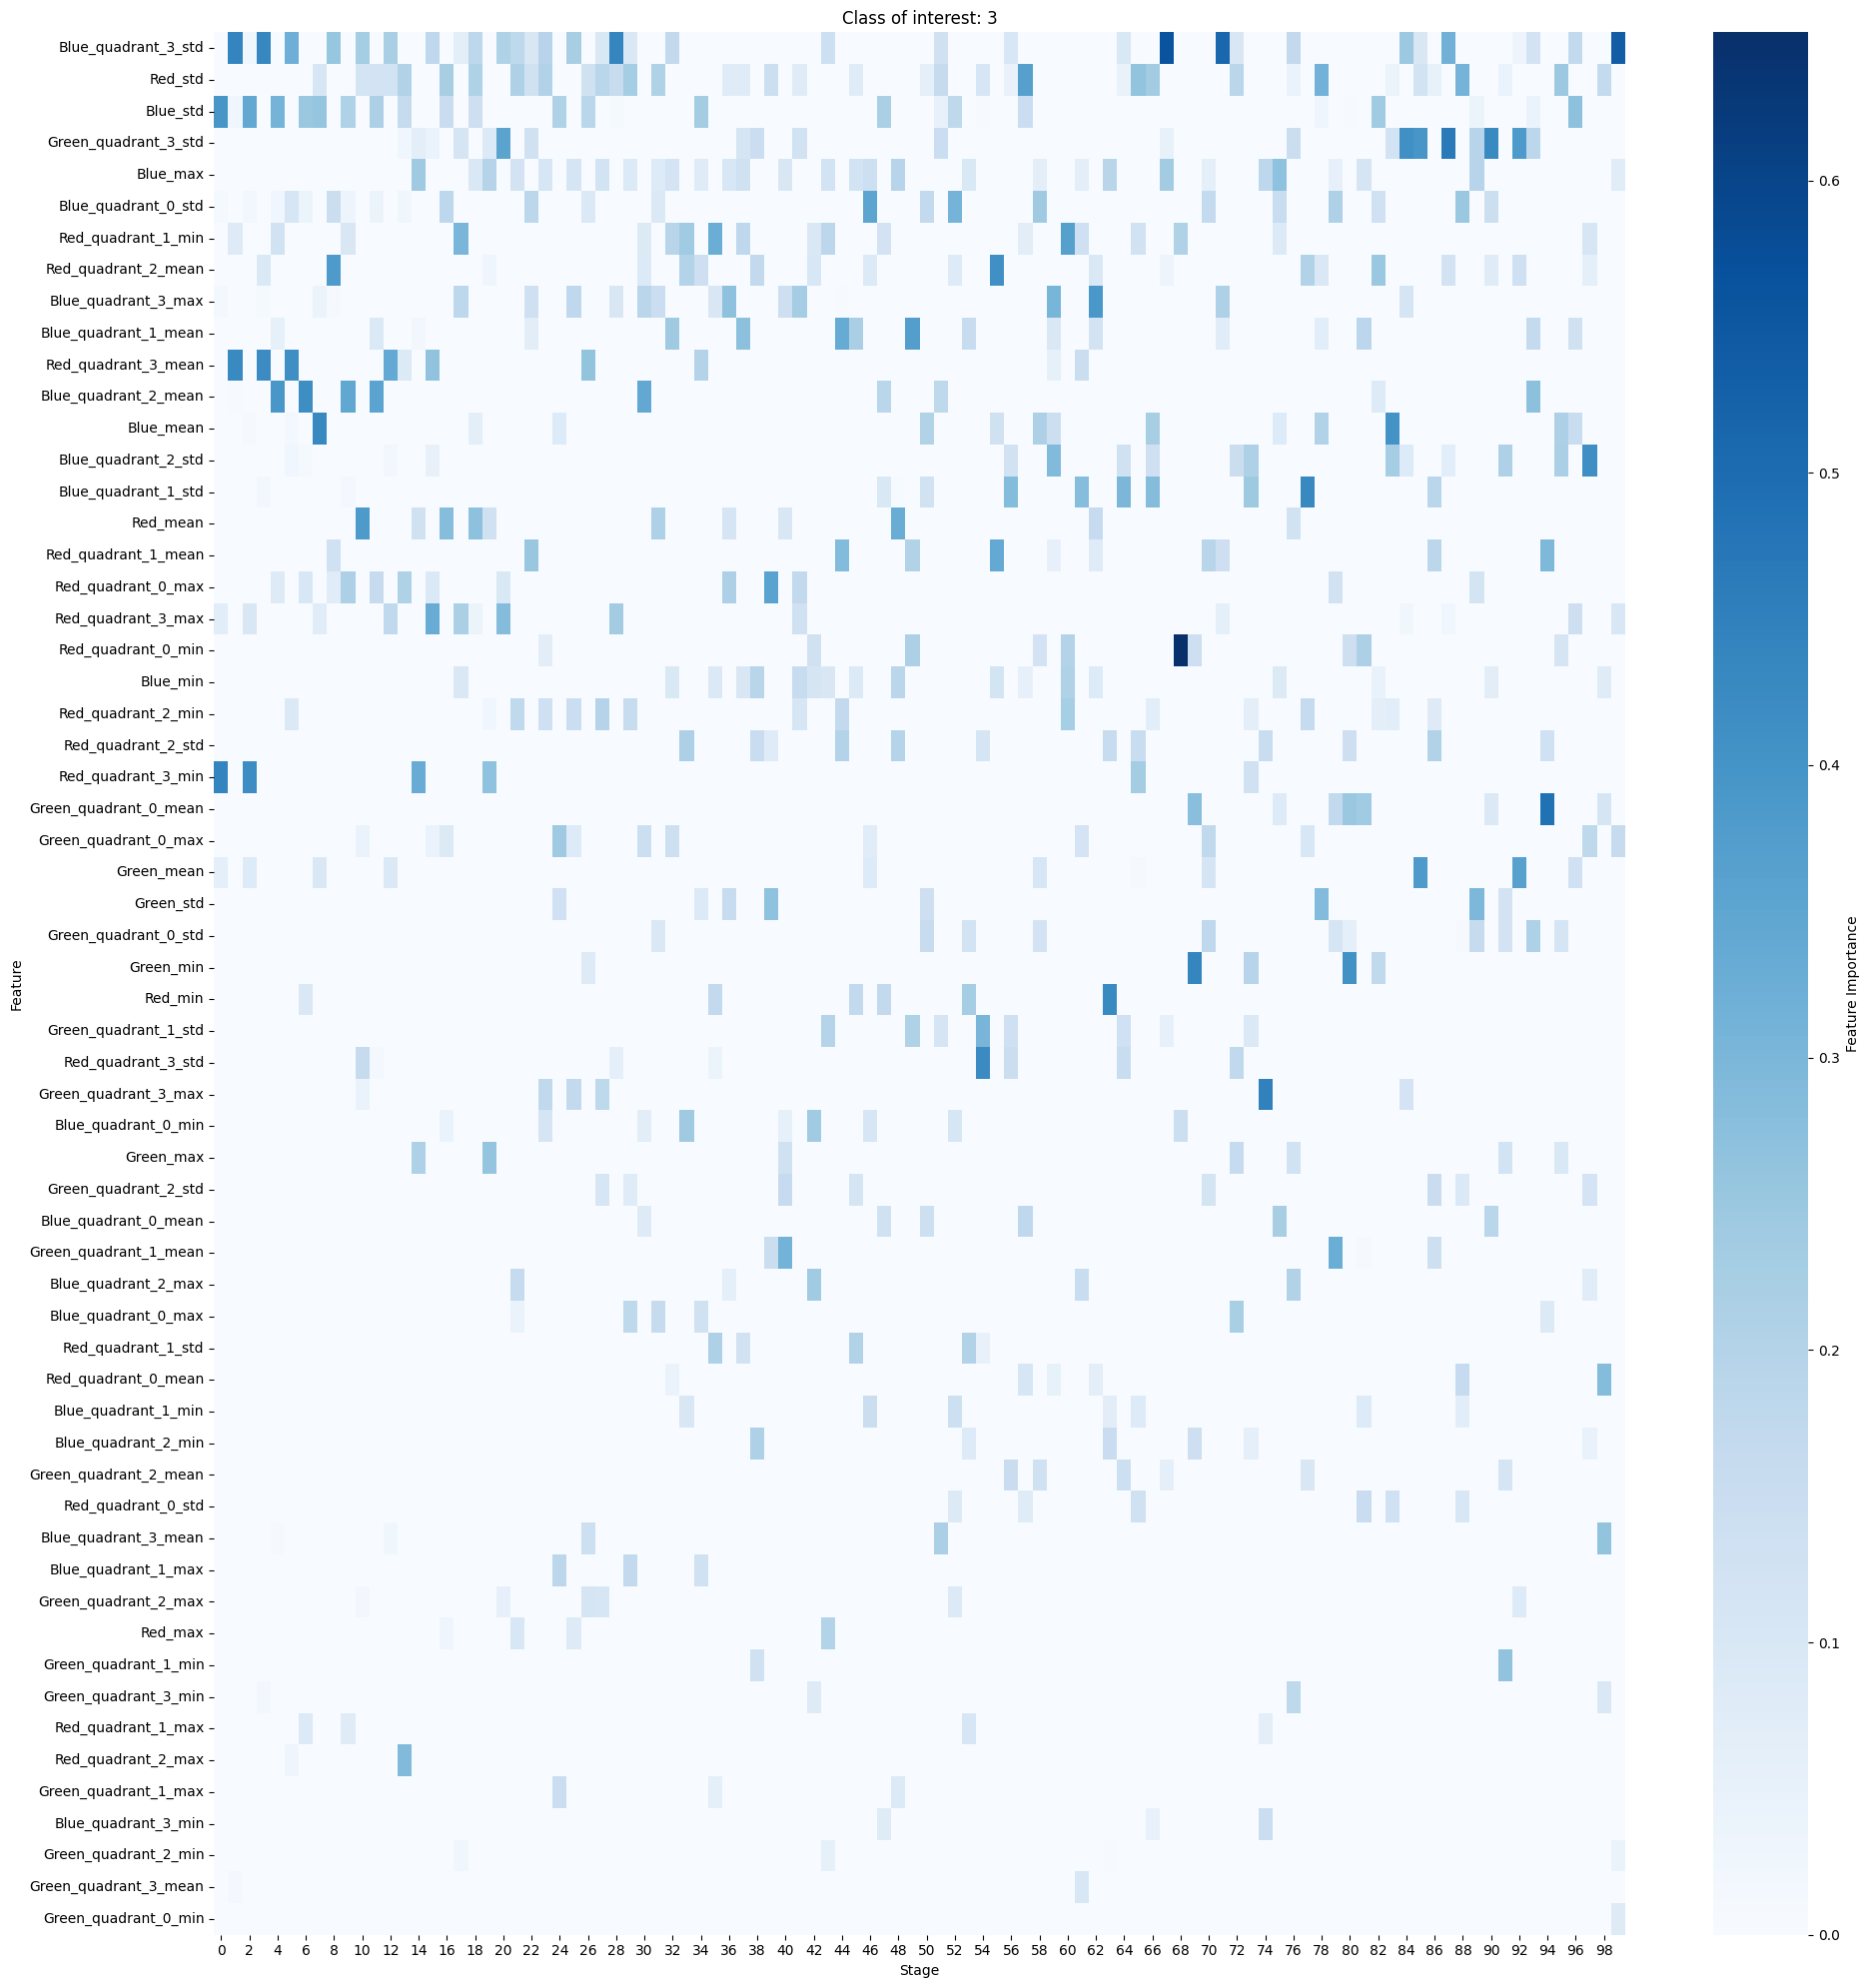

In [39]:
# filter class of interest
class_of_interest = 3
dict_tree_importances = dict_tree_importances_per_class[class_of_interest]

# from dict to dataframe
df_tree_importances = pd.DataFrame(dict_tree_importances, index=feature_names)

# get mean importance across stages
df_tree_importances["mean_importance"] = df_tree_importances.mean(axis=1)

# sort by mean importance
df_tree_importances = df_tree_importances.sort_values(by="mean_importance", ascending=False)

# plot verticlal barplot
plt.figure(figsize=(10, 10))
sns.barplot(x="mean_importance", y=df_tree_importances.index, data=df_tree_importances, palette="Blues", hue=df_tree_importances.index)
plt.title(f"Class of interest: {class_of_interest}")
plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# plot heatmap of feature importance across stages
plt.figure(figsize=(20, 20))
sns.heatmap(df_tree_importances.drop(columns=["mean_importance"]), cmap="Blues", cbar_kws={'label': 'Feature Importance'})
plt.title(f"Class of interest: {class_of_interest}")
plt.xlabel("Stage")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [56]:
class_A = 3
class_B = 8